# 04 — Implementing a VAE (Variational Autoencoder) for Image Generation

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement the VAE architecture: encoder → (μ, log σ²) → reparameterized z → decoder
- Understand variational inference: the reparameterization trick and the ELBO loss
- **Generate images** by decoding samples from the latent prior
- Apply a VAE to a real task: anomaly detection by reconstruction error

## 🔗 Where this fits

**Builds on:** Course 08 (AIAT 122) — Unit 4, lesson 02 (a VAE for anomaly detection) and Course 01 (AIAT 111) — Unit 3, lesson 04: the ELBO is just another loss, minimised by the same gradient descent.

**Used later in:** Course 10 — Unit 3, which rebuilds this VAE step by step and adds conditioning, β-VAE and denoising.

---

This notebook covers practical activities from **Course 10, Unit 1**:
- Implementing a VAE (Variational Autoencoder) for image generation

---

## Introduction

A **VAE** is the deep, continuous version of the latent-variable model from example 03: an **encoder** network maps each image to a Gaussian over latent space (mean μ and log-variance), a **decoder** network maps latent vectors back to images, and training maximizes the **ELBO** — reconstruction quality plus a KL term that keeps the latent space close to N(0, I) so we can generate by sampling z ~ N(0, I) and decoding.

---

## 🌍 Why this lesson exists — MVTec AD and the industrial-inspection benchmark

Part 2 of this notebook runs the pattern that industrial inspection is built on: model *normal*, threshold the reconstruction error. That pattern was being reported on datasets that flattered it, so MVTec built a benchmark to make the claim measurable — **MVTec AD** (Bergmann, Fauser, Sattlegger & Steger, CVPR 2019): 5,354 real high-resolution images across 15 object and texture categories, with 73 defect types and pixel-accurate ground-truth masks. It is now the standard yardstick for exactly the method you are about to build, and reconstruction-based detectors are measured against it rather than demonstrated on hand-picked examples.

**What goes wrong without this:** for defects, fraud and intrusion you cannot collect a balanced labelled dataset. You have thousands of normal examples and a handful of failures you have never seen before. A supervised classifier has nothing to learn the rare class from; a generative model of "normal" needs only the normal data, which is the data you actually have.


In [1]:
# WHAT/WHY: import PyTorch and plotting — everything in this notebook is
# pure PyTorch + torchvision (MNIST), no external model downloads.
import numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import torchvision, torchvision.transforms as T
print(f'PyTorch {torch.__version__}')


PyTorch 2.13.0


## Part 1 — Build and Train the VAE on MNIST

Three pieces to watch for in the code:

1. **Encoder** outputs *two* vectors per image: μ and log σ² — a full Gaussian per input, not a single point.
2. **Reparameterization trick**: `z = μ + σ·ε` with `ε ~ N(0,1)` — moves the randomness into ε so gradients can flow through μ and σ.
3. **ELBO loss** = reconstruction loss (binary cross-entropy per pixel) + KL divergence to N(0, I). The KL term is what makes the latent space *sampleable* afterwards.


Epoch 1/4 — avg ELBO loss per image: 246.94


Epoch 2/4 — avg ELBO loss per image: 174.00


Epoch 3/4 — avg ELBO loss per image: 151.33


Epoch 4/4 — avg ELBO loss per image: 139.61


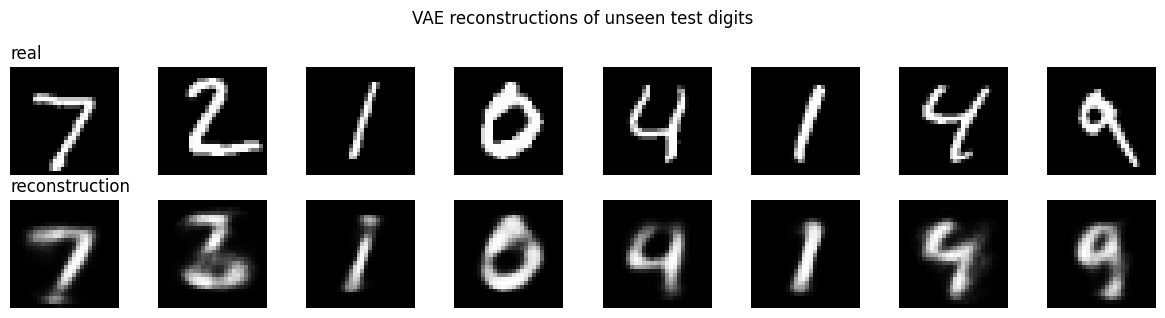

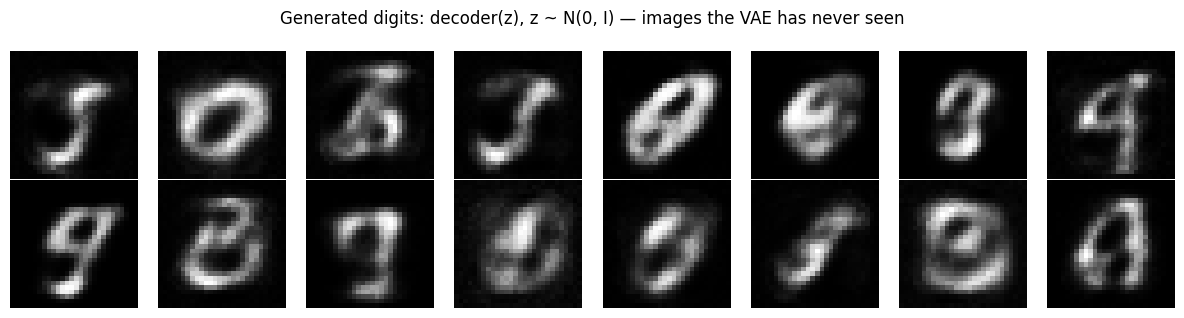

Generation recipe: sample z from the prior, decode. The KL term in the
loss is what made the prior a valid place to sample from.


In [2]:
# WHAT/WHY: train a small VAE on real MNIST digits, then show the three
# outputs that matter: (a) reconstructions of real digits, (b) brand-new
# digits generated by decoding z ~ N(0, I) — the "image generation" this
# notebook promises — and (c) the training loss falling.
torch.manual_seed(42)
LATENT = 16          # size of the latent vector z
EPOCHS = 4
BATCH  = 128

# ── Data: a 12,800-image MNIST subset keeps CPU training fast ─────────────
dataset = torchvision.datasets.MNIST('./data/mnist', train=True, download=True,
                                     transform=T.ToTensor())
subset  = torch.utils.data.Subset(dataset, range(12_800))
loader  = torch.utils.data.DataLoader(subset, batch_size=BATCH, shuffle=True)

# ── VAE: encoder → (mu, logvar) → reparameterized z → decoder ─────────────
class VAE(nn.Module):
    def __init__(self, z=LATENT):
        super().__init__()
        self.enc    = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU())
        self.mu     = nn.Linear(256, z)      # head 1: mean of q(z|x)
        self.logvar = nn.Linear(256, z)      # head 2: log-variance of q(z|x)
        self.dec    = nn.Sequential(nn.Linear(z, 256), nn.ReLU(),
                                    nn.Linear(256, 784), nn.Sigmoid())
    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)
    def reparameterize(self, mu, logvar):
        # z = mu + sigma * eps — randomness lives in eps, gradients flow to mu/sigma
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
    def decode(self, z):
        return self.dec(z).view(-1, 1, 28, 28)
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

vae = VAE()
opt = optim.Adam(vae.parameters(), lr=1e-3)

# ── Storyboard capture: ONE fixed batch of latent vectors, decoded after every
# epoch. Because z is frozen, the grid in the next cell shows the SAME eight
# images sharpening as the decoder learns — not eight new lucky draws.
# Drawn from its OWN generator so the storyboard does not disturb the random
# stream training uses — the printed losses stay reproducible.
snap_rng = torch.Generator().manual_seed(7)
fixed_z  = torch.randn(8, LATENT, generator=snap_rng)
with torch.no_grad():
    snapshots = [vae.decode(fixed_z).squeeze(1).numpy()]   # epoch 0: untrained decoder
epoch_losses = []

# ── Training loop: ELBO = reconstruction BCE + KL(q(z|x) || N(0, I)) ──────
for epoch in range(EPOCHS):
    total = 0.0
    for x, _ in loader:
        recon, mu, logvar = vae(x)
        recon_loss = F.binary_cross_entropy(recon, x, reduction='sum')
        kl_loss    = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = (recon_loss + kl_loss) / x.size(0)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    epoch_losses.append(total / len(loader))
    with torch.no_grad():
        snapshots.append(vae.decode(fixed_z).squeeze(1).numpy())  # same z, one epoch later
    print(f"Epoch {epoch+1}/{EPOCHS} — avg ELBO loss per image: {total/len(loader):.2f}")

# ── (a) Reconstructions: top row = real digits, bottom row = VAE output ───
vae.eval()
test_ds = torchvision.datasets.MNIST('./data/mnist', train=False, transform=T.ToTensor())
x_test  = torch.stack([test_ds[i][0] for i in range(8)])
with torch.no_grad():
    recon, _, _ = vae(x_test)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i in range(8):
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray');  axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].squeeze(),  cmap='gray');  axes[1, i].axis('off')
axes[0, 0].set_title("real", loc='left'); axes[1, 0].set_title("reconstruction", loc='left')
plt.suptitle("VAE reconstructions of unseen test digits")
plt.tight_layout(); plt.show()

# ── (b) GENERATION: decode z ~ N(0, I) — brand-new digits from noise ──────
with torch.no_grad():
    z_prior   = torch.randn(16, LATENT)       # sample the prior
    generated = vae.decode(z_prior)           # decode → new images

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].squeeze(), cmap='gray'); ax.axis('off')
plt.suptitle("Generated digits: decoder(z), z ~ N(0, I) — images the VAE has never seen")
plt.tight_layout(); plt.show()

print("Generation recipe: sample z from the prior, decode. The KL term in the")
print("loss is what made the prior a valid place to sample from.")


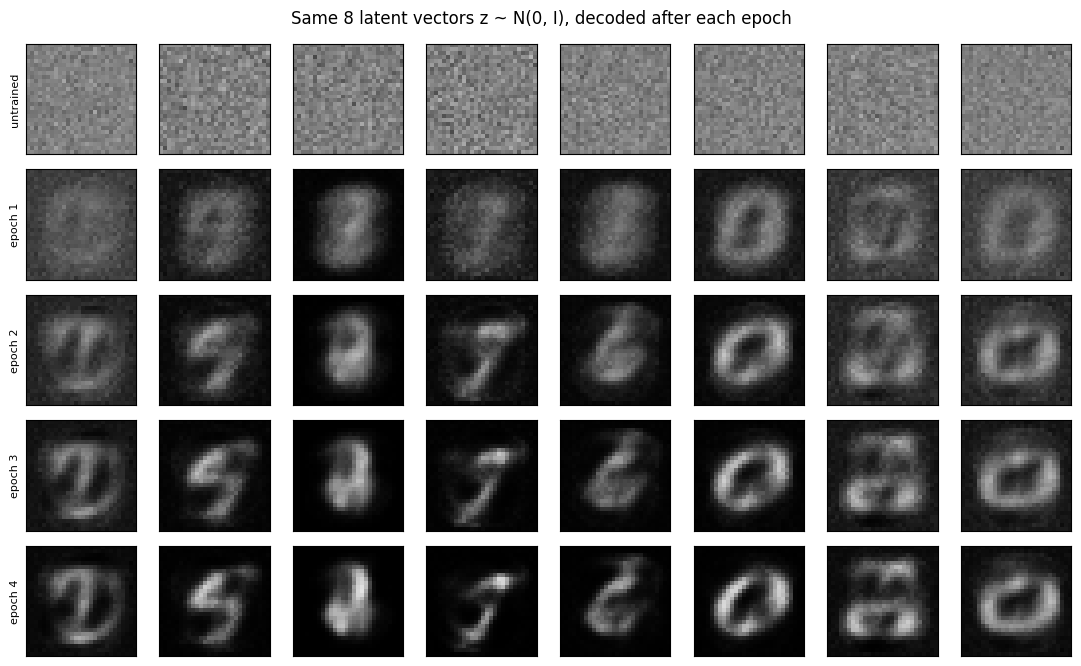

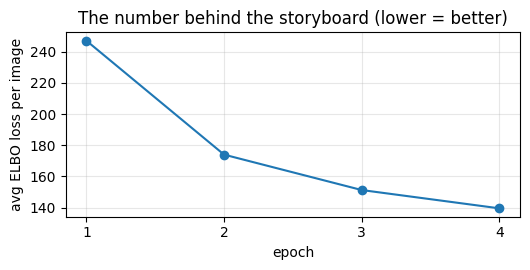

epoch   avg ELBO loss/image   improvement vs previous
   1            246.94               —
   2            174.00           +72.94
   3            151.33           +22.67
   4            139.61           +11.71


In [3]:
# WHAT/WHY: the two pictures the printed loss numbers only hint at —
# (1) a storyboard of the SAME eight latent vectors decoded after each epoch,
# (2) the ELBO loss curve those epochs produced. Together they show that the
# falling number and the improving images are the same event.
fig, axes = plt.subplots(len(snapshots), 8, figsize=(11, 1.35 * len(snapshots)))
for r, frame in enumerate(snapshots):
    for c in range(8):
        axes[r, c].imshow(frame[c], cmap='gray', vmin=0, vmax=1)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    axes[r, 0].set_ylabel("untrained" if r == 0 else f"epoch {r}", fontsize=8)
plt.suptitle("Same 8 latent vectors z ~ N(0, I), decoded after each epoch")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(5.4, 2.8))
ax.plot(range(1, EPOCHS + 1), epoch_losses, 'o-')
ax.set_xlabel("epoch"); ax.set_ylabel("avg ELBO loss per image")
ax.set_xticks(range(1, EPOCHS + 1)); ax.grid(alpha=0.3)
ax.set_title("The number behind the storyboard (lower = better)")
plt.tight_layout(); plt.show()

print("epoch   avg ELBO loss/image   improvement vs previous")
for i, v in enumerate(epoch_losses, start=1):
    delta = "     —" if i == 1 else f"{epoch_losses[i-2] - v:+7.2f}"
    print(f"{i:>4}          {v:8.2f}          {delta}")

**Read the storyboard against the curve.** The top row is the decoder *before any training*: the same eight latent vectors produce grey static, because random weights map every z to noise. One epoch later every column holds a faint digit-like shape on a black field; by epoch 2 most columns have settled on an identity, and the last two rows mainly sharpen what is already there. Each column keeps its own identity as it improves, because its `z` never changes — and a couple of columns stay ambiguous blobs even at epoch 4, which is the honest state of a 16-dimensional VAE trained for four CPU epochs.

The curve underneath is the same epochs measured instead of looked at, and the printed table gives the size of each step: the improvement is +72.9 from epoch 1 to 2, then +22.7, then +11.7. The steepest drop is exactly where the storyboard changes most, and the flattening tail is why the last two rows differ far less from each other than the first two do. That correspondence is the point: a generative model's loss number and its sample quality are supposed to move together, and here you can check that they did instead of taking it on trust.

## Part 2 — 🌍 Real-World Worked Example: VAE Anomaly Detection on MNIST

**Industry context:**
- **Manufacturing:** VAE-style models flag defective parts on assembly lines
- **Finance:** payment providers score transactions by how badly they reconstruct
- **Healthcare:** anomalous medical scans reconstruct poorly under a model of normal scans

The idea: train the VAE **only on "normal" data** (here: the digit 0). Anything it has never seen (here: the digit 1) reconstructs badly — high reconstruction error = anomaly flag.


Training VAE on class 0 only (5 epochs)...
  Epoch 1/5 — loss=285.06


  Epoch 2/5 — loss=185.87
  Epoch 3/5 — loss=165.22


  Epoch 4/5 — loss=153.97
  Epoch 5/5 — loss=145.63

Anomaly detection results:
  Normal (class 0) avg error:  0.1547
  Anomaly (class 1) avg error: 0.2996
  Anomaly detection rate: 100%
  (Threshold = 90th percentile of normal errors: 0.1944)


/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_52232/2658866438.py:79: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(); plt.show()


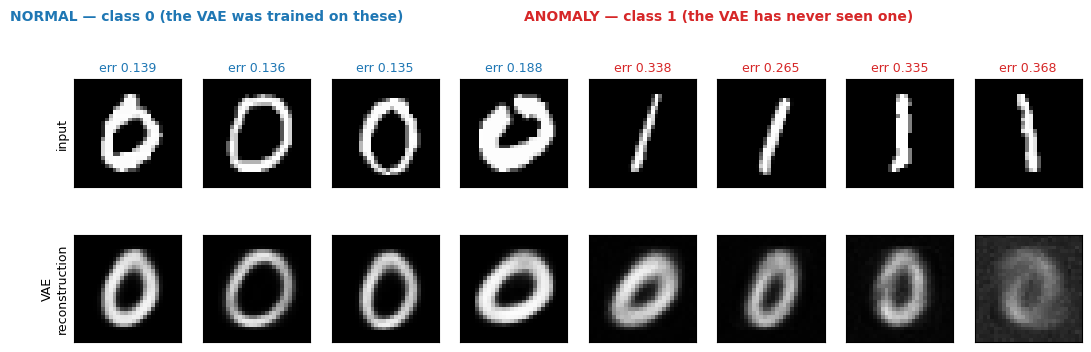

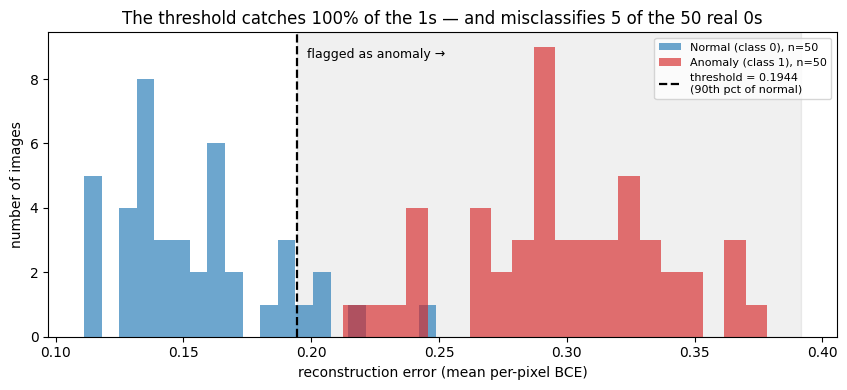

In [4]:
# WHAT/WHY: train a VAE only on digit 0, then score unseen digits by
# reconstruction error — 0s reconstruct well (low error), 1s reconstruct badly
# (high error). Thresholding that error is a production anomaly-detection
# pattern. The histogram at the end shows the two error distributions.
torch.manual_seed(42)
BATCH = 128

train_ds = torchvision.datasets.MNIST('./data/mnist', train=True,  download=True, transform=T.ToTensor())
test_ds  = torchvision.datasets.MNIST('./data/mnist', train=False, download=True, transform=T.ToTensor())

# ── "Normal" training set: class 0 only ───────────────────────────────────
train_0 = torch.utils.data.Subset(train_ds, [i for i in range(len(train_ds)) if train_ds[i][1] == 0])
loader  = torch.utils.data.DataLoader(train_0, batch_size=BATCH, shuffle=True)

# ── Fresh VAE (same architecture as Part 1) trained on 0s only ────────────
model = VAE()
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Training VAE on class 0 only (5 epochs)...")
for epoch in range(5):
    total = 0.0
    for i, (x, _) in enumerate(loader):
        recon, mu, logvar = model(x)
        bce = F.binary_cross_entropy(recon, x, reduction='sum')
        kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = (bce + kld) / x.size(0)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    print(f"  Epoch {epoch+1}/5 — loss={total/(i+1):.2f}")

# ── Score unseen images by per-pixel reconstruction error ─────────────────
model.eval()
def recon_errors(images):
    x = torch.stack(images)
    with torch.no_grad():
        r, mu, logvar = model(x)
    return F.binary_cross_entropy(r.view(len(x), -1), x.view(len(x), -1),
                                  reduction='none').mean(1).numpy()

normal_imgs  = [test_ds[i][0] for i in range(500) if test_ds[i][1] == 0][:50]  # seen class
anomaly_imgs = [test_ds[i][0] for i in range(500) if test_ds[i][1] == 1][:50]  # unseen class
normal_err   = recon_errors(normal_imgs)
anomaly_err  = recon_errors(anomaly_imgs)

# ── Threshold at the 90th percentile of normal errors, count detections ───
threshold    = np.percentile(normal_err, 90)
pct_detected = (anomaly_err > threshold).mean() * 100

print("\nAnomaly detection results:")
print(f"  Normal (class 0) avg error:  {normal_err.mean():.4f}")
print(f"  Anomaly (class 1) avg error: {anomaly_err.mean():.4f}")
print(f"  Anomaly detection rate: {pct_detected:.0f}%")
print(f"  (Threshold = 90th percentile of normal errors: {threshold:.4f})")

# ── FIGURE 1: WHY the error differs — look at what the model actually draws ──
# Four 0s (the class it was trained on) and four 1s (never seen), each shown as
# input above its reconstruction, with that image's own error printed on it.
# This is the mechanism the histogram below only summarises.
show_n, show_a = normal_imgs[:4], anomaly_imgs[:4]
with torch.no_grad():
    rec_n, _, _ = model(torch.stack(show_n))
    rec_a, _, _ = model(torch.stack(show_a))

fig, axes = plt.subplots(2, 8, figsize=(13, 3.7))
for i in range(4):
    for col, (img, rec, err) in [(i,     (show_n[i], rec_n[i], normal_err[i])),
                                 (i + 4, (show_a[i], rec_a[i], anomaly_err[i]))]:
        axes[0, col].imshow(img.squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[1, col].imshow(rec.squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[0, col].set_title(f"err {err:.3f}", fontsize=9,
                               color=("tab:blue" if col < 4 else "tab:red"))
        for r in range(2):
            axes[r, col].set_xticks([]); axes[r, col].set_yticks([])
axes[0, 0].set_ylabel("input", fontsize=9); axes[1, 0].set_ylabel("VAE\nreconstruction", fontsize=9)
axes[0, 0].text(-0.6, 1.55, "NORMAL — class 0 (the VAE was trained on these)",
                transform=axes[0, 0].transAxes, fontsize=10, color="tab:blue", fontweight="bold")
axes[0, 4].text(-0.6, 1.55, "ANOMALY — class 1 (the VAE has never seen one)",
                transform=axes[0, 4].transAxes, fontsize=10, color="tab:red", fontweight="bold")
plt.tight_layout(); plt.show()

# ── FIGURE 2: the two error distributions, with the decision region shaded ───
fig, ax = plt.subplots(figsize=(8.6, 4))
ax.hist(normal_err,  bins=20, alpha=0.65, label='Normal (class 0), n=50',  color='tab:blue')
ax.hist(anomaly_err, bins=20, alpha=0.65, label='Anomaly (class 1), n=50', color='tab:red')
ax.axvline(threshold, color='black', linestyle='--', lw=1.6,
           label=f'threshold = {threshold:.4f}\n(90th pct of normal)')
ax.axvspan(threshold, ax.get_xlim()[1], color='black', alpha=0.06, zorder=0)
ax.text(threshold + 0.004, ax.get_ylim()[1] * 0.95, "flagged as anomaly →",
        fontsize=9, va="top")
ax.set_xlabel("reconstruction error (mean per-pixel BCE)"); ax.set_ylabel("number of images")
ax.set_title(f"The threshold catches {pct_detected:.0f}% of the 1s — and misclassifies "
             f"{(normal_err > threshold).sum()} of the 50 real 0s")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


**Read the two figures.**

*The image grid* is the mechanism. On the left, four real 0s and what the VAE rebuilds from them: blurry, but unmistakably the same digit — this decoder has seen thousands of 0s and knows the shape. On the right, four real 1s. The VAE does not draw a 1 — it draws a **0**. Blurry, off-centre, and in the last column barely lit, but unmistakably the wrong digit: a decoder trained only on 0s has no way to represent a thin vertical stroke, so the nearest thing it can say is the only thing it knows. The per-image errors printed above each column are roughly twice as large on the right as on the left, and the picture shows exactly what that number is measuring: the model was asked to describe something outside its world and produced something else.

*The histogram* is the same fact for 100 images at once. The blue distribution (real 0s) sits low and tight; the red one (unseen 1s) sits clearly to its right, and the two barely overlap. Every red bar to the right of the dashed line is a caught anomaly — here, all of them.

But read the blue bars to the right of the line too. Those are perfectly normal 0s that this threshold flags anyway, and there are five of them *by construction*: the threshold was defined as the 90th percentile of normal error, so 10% of normal images are sacrificed before a single anomaly is seen. Nothing about the model chose that trade — see discussion question 1.

## 💬 Discuss

1. Our detector flagged **100% of the 1s** at a threshold set to the **90th percentile of normal error (0.1944)** — that is, we accepted a 10% false-alarm rate *by construction*. On a line producing 10,000 parts a shift, is that threshold defensible? Where would you move it, and what exactly do you give up?
2. Digit 1 is the easiest possible anomaly against a model of 0s: thin strokes, few lit pixels, completely different topology. Which digit would you expect this same detector to *miss*, and how would you test that before shipping rather than after?
3. The model never sees a labelled anomaly. So how do you convince a factory manager the system works, when you cannot show him a precision/recall table for defects you do not have examples of? Write the two sentences you would actually say.


## ⚠️ Where this breaks

**Reconstruction error confounds "anomalous" with "hard to reconstruct".** A perfectly normal but unusual-looking sample — a rare valid part, an unusually dark scan, a legitimate but atypical transaction — scores high and gets flagged. A subtle defect covering twenty pixels barely moves the average and gets missed. The detector is strongest exactly where the anomaly is *large*, which is where you needed it least.

**The VAE's blur is a systematic error floor.** Our normal class already reconstructs imperfectly (average error **0.1547**). Any defect whose reconstruction cost is smaller than that floor is invisible to this method, no matter how you set the threshold.

**The threshold is a business decision wearing a percentile costume.** Nothing in the model chose the 90th percentile. Someone has to decide what a false alarm costs against what a missed defect costs, and that person is not the model.

**Cheaper alternative:** if you *do* have a few hundred labelled defects, a supervised classifier will beat this comfortably. Reconstruction-based anomaly detection is what you do when labelled anomalies are the thing you cannot get.


---

## 🔭 State of the field (2026)

*Enrichment, not examinable content — the official unit examines the technique above exactly as it is taught. This box says where that technique sits on the 2026 map.*

Nobody ships a plain VAE as a standalone image generator in 2026 — the blur you measured above is the reason,
and it is a consequence of the ELBO, not of your training budget. What happened instead is more useful to you
than a replacement would have been: **the VAE became the compressor that modern generators run inside.** Latent
diffusion moved the entire generative process into a learned latent space (Rombach *et al.* 2022, listed below),
that design carried into the current rectified-flow text-to-image transformers (Esser *et al.* 2024), and an
active research line pushes the same autoencoder to high spatial compression ratios — 64× and beyond — precisely
because that is what makes high-resolution generation affordable (Chen *et al.* 2024).

**Why this lesson is still exactly the right thing to learn.** The encoder with its μ and log σ² heads, the
reparameterization trick, and the KL term you weighed against reconstruction error are the *first stage* of the
pipeline every text-to-image system runs — you are building the component, not a museum piece. And Part 2 is a
VAE application that never wanted a generator at all: reconstruction-error anomaly detection is deployed work in
manufacturing and fraud, and it needs precisely the model you trained here. This is also what the official plan
examines.

**Read:** Esser *et al.* (2024), <https://arxiv.org/abs/2403.03206> · Chen *et al.* (2024),
<https://arxiv.org/abs/2410.10733> (both listed below).

---

## 📚 References & Further Reading

**Papers:**
- Kingma & Welling (2014) — [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114) *(the VAE paper)*
- Higgins et al. (2017) — [β-VAE: Learning Basic Visual Concepts](https://openreview.net/forum?id=Sy2fchgcx)
- Doersch (2016) — [Tutorial on Variational Autoencoders](https://arxiv.org/abs/1606.05908)
- Rombach et al. (2022) — [High-Resolution Image Synthesis with Latent Diffusion Models](https://arxiv.org/abs/2112.10752) *(Stable Diffusion — runs diffusion inside a VAE latent space like the one you just built)*

**State-of-the-Art:**
- Stable Diffusion runs its diffusion process inside a **VAE latent space** — the architecture you just built is a core component of modern text-to-image systems (diffusion itself is taught in Unit 3, example 04)

**Recent (2024–2026) — where your encoder/decoder actually runs in production:**
- Chen et al. (2024) — [Deep Compression Autoencoder for Efficient High-Resolution Diffusion Models](https://arxiv.org/abs/2410.10733) *(pushing the same autoencoder to high spatial compression ratios, e.g. 64×, so high-resolution diffusion becomes affordable)*
- Esser et al. (2024) — [Scaling Rectified Flow Transformers for High-Resolution Image Synthesis](https://arxiv.org/abs/2403.03206) *(the current open text-to-image recipe that generates inside a learned latent space like the one you just built)*
- Page et al. (2026) — [Boosting Latent Diffusion Models via Disentangled Representation Alignment](https://arxiv.org/abs/2601.05823) *(a 2026 view of the same encoder: a VAE tuned for semantic disentanglement rather than reconstruction alone, reporting FID 1.21 on ImageNet 256×256 for flow transformers trained inside its latent space)*


## 📝 Summary

In **04 — Implementing a VAE for Image Generation** you built the full VAE pipeline: encoder with μ/log σ² heads, the reparameterization trick, and the ELBO loss; you **generated new digit images by decoding samples from the prior** (see the "Generated digits" figure); and you applied the same model to anomaly detection, where the class the VAE never saw produced clearly higher reconstruction errors (compare the printed averages). Next: example 05 builds the other core architecture — the GAN.
